In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read new data
df = pd.read_csv('/home/moorche10/Desktop/note_books/divar_new.csv')
df.shape

/tmp/ipykernel_7298/1309079477.py:2: DtypeWarning: Columns (16,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/moorche10/Desktop/note_books/divar_new.csv')


(424442, 37)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424442 entries, 0 to 424441
Data columns (total 37 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   cat2_slug                424442 non-null  object 
 1   cat3_slug                424442 non-null  object 
 2   city_slug                424442 non-null  object 
 3   neighborhood_slug        424442 non-null  object 
 4   user_type                424442 non-null  object 
 5   description              424442 non-null  object 
 6   title                    424442 non-null  object 
 7   price_mode               424442 non-null  object 
 8   price_value              424442 non-null  float64
 9   land_size                424442 non-null  float64
 10  building_size            424442 non-null  float64
 11  deed_type                424442 non-null  object 
 12  floor                    424442 non-null  float64
 13  rooms_count              424442 non-null  float64
 14  tota

In [4]:
df.describe()

,price_value,land_size,building_size,floor,rooms_count,total_floors_count,unit_per_floor,location_latitude,location_longitude
count,4.244420e+05,4.244420e+05,4.244420e+05,424442.000000,424442.000000,424442.000000,424442.000000,424442.000000,424442.000000
mean,1.547958e+10,1.483944e+03,1.085004e+03,2.894167,3.087694,4.981347,2.147504,35.125567,51.563406
std,5.286585e+11,7.627807e+04,6.493766e+04,1.871161,0.841966,1.827631,0.957505,1.755553,2.433289
min,0.000000e+00,1.000000e+00,1.000000e+00,0.000000,1.000000,2.000000,1.000000,23.636976,43.774818
25%,1.720000e+09,7.700000e+01,7.500000e+01,2.000000,3.000000,5.000000,2.000000,35.046600,51.020851
50%,3.100000e+09,1.050000e+02,1.000000e+02,3.000000,3.000000,5.000000,2.000000,35.297815,51.546260
75%,6.050000e+09,1.600000e+02,1.370000e+02,3.000000,3.000000,5.000000,2.000000,35.772238,51.546260
max,1.000000e+14,1.000000e+07,1.000000e+07,30.000000,6.000000,30.000000,8.000000,40.358055,62.558594


In [5]:
# Only numeric cols
df=df.drop(["cat2_slug","cat3_slug","city_slug","neighborhood_slug","user_type","description","title",
           "price_mode","deed_type","has_balcony","has_elevator","has_warehouse","has_parking",
           "is_rebuilt","has_water","has_warm_water_provider","has_electricity","has_gas","has_heating_system",
           "has_cooling_system","has_restroom","has_barbecue","building_direction","has_pool","has_jacuzzi",
           "has_sauna","floor_material"],axis=1)
df.shape

(424442, 10)

In [6]:
df=df.drop(["location_latitude","location_longitude"],axis=1)

In [7]:
df["construction_year"].unique()

array(['۱۳۸۴', '۱۴۰۳', '۱۳۹۳', '۱۳۹۶', '۱۳۸۷', '۱۴۰۲', '۱۳۸۸', '۱۳۹۸',
       '۱۴۰۰', '۱۳۹۲', '۱۴۰۱', '۱۳۹۴', '۱۳۸۳', '۱۳۹۹', '۱۳۹۰', '۱۳۸۵',
       '۱۳۸۲', '۱۳۹۵', '۱۳۹۱', '۱۳۸۶', '۱۳۸۰', '۱۳۷۵', '۱۳۹۷', '۱۳۷۲',
       '۱۳۷۴', 'قبل از ۱۳۷۰', '۱۳۸۹', '۱۳۷۹', '۱۳۷۱', '۱۳۸۱', '۱۳۷۳',
       '۱۳۷۸', '۱۳۷۷', '۱۳۷۶'], dtype=object)

In [8]:
df = df[~df["construction_year"].str.contains('قبل از ۱۳۷۰',na=True)]

In [9]:
def persian_to_english_numbers(text):
    if pd.isna(text):
        return text
    persian_numbers = "۰۱۲۳۴۵۶۷۸۹"
    english_numbers = "0123456789"
    translation_table=str.maketrans(persian_numbers,english_numbers)
    return str(text).translate(translation_table)
df["construction_year"]=df["construction_year"].apply(persian_to_english_numbers)
df["construction_year"]=pd.to_numeric(df["construction_year"],errors="coerce")

In [10]:
df["construction_year"].unique()

array([1384, 1403, 1393, 1396, 1387, 1402, 1388, 1398, 1400, 1392, 1401,
       1394, 1383, 1399, 1390, 1385, 1382, 1395, 1391, 1386, 1380, 1375,
       1397, 1372, 1374, 1389, 1379, 1371, 1381, 1373, 1378, 1377, 1376])

In [11]:
df.head()

,price_value,land_size,building_size,floor,rooms_count,total_floors_count,unit_per_floor,construction_year
0,8.500000e+09,60.0,60.0,3.0,2.0,5.0,2.0,1384
1,5.750000e+09,115.0,115.0,4.0,3.0,6.0,2.0,1403
2,8.700000e+09,100.0,100.0,4.0,3.0,5.0,2.0,1393
3,6.500000e+08,78.0,78.0,4.0,3.0,6.0,4.0,1396
4,3.000000e+09,80.0,80.0,3.0,3.0,5.0,2.0,1387


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [14]:
# PCA
# X = df.drop("price_value",axis=1)
# y = df["price_value"]
X = df
y = None
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
pca = PCA(n_components=8).fit(X_scaled)
pca.explained_variance_

array([1.74950972, 1.46025281, 1.15542732, 0.99920664, 0.85929974,
       0.73777081, 0.53979357, 0.49875865])

In [17]:
pca = PCA(n_components=6)
pca_features = pca.fit_transform(X_scaled)
print('Shape before PCA: ', X_scaled.shape)
print('Shape after PCA: ', pca_features.shape)

Shape before PCA:  (415486, 8)
Shape after PCA:  (415486, 6)


In [19]:
pca_df=pd.DataFrame(
    data=pca_features,
    columns=["PCA1","PCA2","PCA3","PCA4","PCA5","PCA6"])
pca_df

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6
0,-0.605722,-0.031070,-1.618150,0.178251,-0.491967,-0.788636
1,0.857434,-0.002608,0.535663,-0.139193,0.714955,-0.472778
2,0.181399,-0.021683,-0.110809,0.012155,-0.304881,-0.516352
3,1.558537,-0.005495,-0.911313,0.040654,0.177956,0.844294
4,-0.318788,-0.035185,-0.566471,0.093532,-0.836129,-0.240104
...,...,...,...,...,...,...
415481,1.213979,-0.006211,1.823808,-0.214184,-0.201642,-0.986558
415482,-0.445303,-0.021621,0.360347,-0.109574,0.866799,0.509896
415483,-0.326815,-0.033241,-0.405724,0.073398,-0.794347,-0.521703
415484,-0.146822,-0.018180,0.391361,-0.111232,0.759535,0.188125


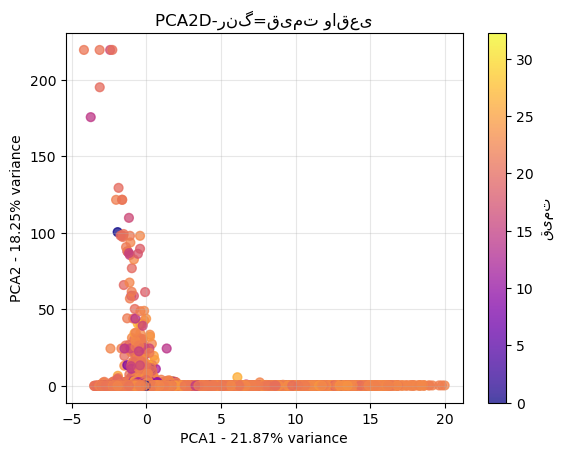

واریانس با دو کامپوننت:87.02%


In [20]:
pca2d = PCA(n_components=6)
x_pca2d = pca2d.fit_transform(X_scaled)
viz_df = pd.DataFrame({
    "PCA1":x_pca2d[:,0],
    "PCA2":x_pca2d[:,1],
    "price":np.log1p(df["price_value"].values)})
plt.figure()
scatter = plt.scatter(viz_df["PCA1"],viz_df["PCA2"],
                      c=viz_df["price"],cmap="plasma",alpha=0.75,s=40)
plt.colorbar(scatter,label="قیمت")
plt.title("PCA2D-رنگ=قیمت واقعی")
plt.xlabel(f"PCA1 - {pca2d.explained_variance_ratio_[0]:.2%} variance")
plt.ylabel(f"PCA2 - {pca2d.explained_variance_ratio_[1]:.2%} variance")
plt.grid(True,alpha=0.3)
plt.show()
print(f"واریانس با دو کامپوننت:{pca2d.explained_variance_ratio_.sum():.2%}")

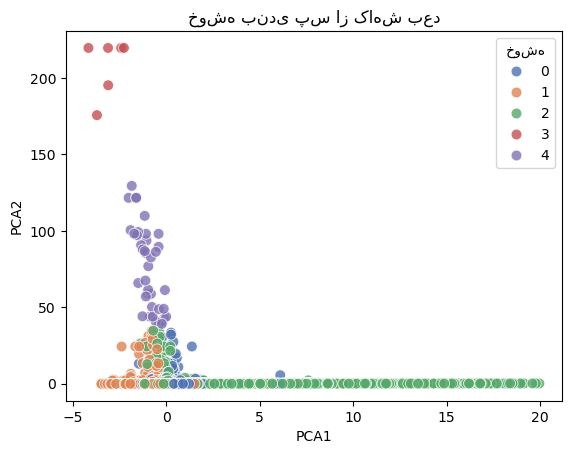

In [24]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5,random_state=42)
clusters = kmeans.fit_predict(x_pca2d)
viz_df["Cluster"]=clusters
plt.figure()
sns.scatterplot(data=viz_df,x="PCA1",y="PCA2",hue="Cluster",palette="deep",s=60,alpha=0.8)
plt.title("خوشه بندی پس از کاهش بعد")
plt.legend(title="خوشه")
plt.show()

In [25]:
viz_analyse = viz_df.copy()
viz_analyse["price_real"]=df["price_value"]
print(viz_analyse.groupby("Cluster")["price_real"].agg(["count","mean","std","min","max"]).round(0))

          count          mean           std          min           max
Cluster                                                               
0         85267  1.339584e+10  3.428985e+11          0.0  4.320000e+13
1        146985  1.647301e+10  6.036906e+11          0.0  1.000000e+14
2        174399  1.533305e+10  5.337266e+11          0.0  1.000000e+14
3             6  2.517685e+09  1.379126e+09  111111111.0  4.250000e+09
4            42  7.914848e+09  1.934449e+10          0.0  1.200000e+11
